In [20]:
import os, sys
import numpy as np
import pandas as pd

from utils.plot_utils import setup_matplotlib

In [27]:
setup_matplotlib()

# === Config ===
train_trajs = ["random", "square", "chirp"]
test_trajs = ["melon"]

# === File paths ===
OUT_FOLDER = os.path.join(
    "..",
    "identification",
    "out",
    "predictions",
    "real"
)

# Ensure the output folder exists
os.makedirs(OUT_FOLDER, exist_ok=True)

# Construct file paths
train_name = "_".join(train_trajs)
test_name = "_".join(test_trajs)

file_lstm = os.path.join(
    OUT_FOLDER,
    f"lstm_v2_{train_name}_model_multistep",
    f"{test_name}_multistep.csv"
)

file_base = os.path.join(
    OUT_FOLDER,
    "baseline_model_multistep",
    f"{test_name}_multistep.csv"
)

file_neur = os.path.join(
    OUT_FOLDER,
    f"neural_v2_{train_name}_model_multistep",
    f"{test_name}_multistep.csv"
)

file_phys = os.path.join(
    OUT_FOLDER,
    f"physics_model_multistep",
    f"{test_name}_multistep.csv"
)
#
file_res = os.path.join(
    OUT_FOLDER,
    f"phys+res_{train_name}_model_multistep",
    f"{test_name}_multistep.csv"
)

print("LSTM file path:", file_lstm)
print("Baseline file path:", file_base)

# === Read CSVs ===
df_lstm = pd.read_csv(file_lstm)
df_base = pd.read_csv(file_base)
df_neur = pd.read_csv(file_neur)
df_phys = pd.read_csv(file_phys)
df_res = pd.read_csv(file_res)

print("✅ Loaded datasets:")
print(f"  LSTM model: {df_lstm.shape}")
print(f"  Baseline model: {df_base.shape}")
print(f"  Neural model: {df_neur.shape}")
print(f"  Physics model: {df_phys.shape}")
print(f"  Residual model: {df_res.shape}")

LSTM file path: ..\identification\out\predictions\real\lstm_v2_random_square_chirp_model_multistep\melon_multistep.csv
Baseline file path: ..\identification\out\predictions\real\baseline_model_multistep\melon_multistep.csv
✅ Loaded datasets:
  LSTM model: (19347, 613)
  Baseline model: (19347, 613)
  Neural model: (19347, 613)
  Physics model: (19347, 613)
  Residual model: (19347, 613)


In [28]:
import torch
from pytorch3d.transforms import quaternion_to_axis_angle, axis_angle_to_quaternion
from scipy.spatial.transform import Rotation as R

def quat_xyzw_to_wxyz(q):
    # (x,y,z,w) → (w,x,y,z)
    return torch.cat([q[..., 3:], q[..., :3]], dim=-1)

def quat_wxyz_to_xyzw(q):
    # (w,x,y,z) → (x,y,z,w)
    return torch.cat([q[..., 1:], q[..., :1]], dim=-1)

def quat_to_so3_log(q_xyzw):
    """Torch: (x,y,z,w) → axis-angle r"""
    q_wxyz = quat_xyzw_to_wxyz(q_xyzw)
    r = quaternion_to_axis_angle(q_wxyz)
    return r

def so3_log_to_quat(r):
    """Torch: axis-angle r → quaternion (x,y,z,w)"""
    q_wxyz = axis_angle_to_quaternion(r)
    q_xyzw = quat_wxyz_to_xyzw(q_wxyz)
    return q_xyzw

def so3_log_to_quat_np(r):
    """
    r: (N,3) rotation vectors
    returns q_xyzw (N,4) = (x,y,z,w)
    """
    rot = R.from_rotvec(r)
    q_wxyz = rot.as_quat()              # (x,y,z,w) ??? NO!
    # scipy uses (x,y,z,w)
    # but we want the same convention as the model: (x,y,z,w)
    return q_wxyz  # already in (x,y,z,w)


def quat_to_euler_np(q_xyzw):
    """
    q: (N,4) in (x,y,z,w)
    Returns euler angles (N,3) in radians
    """
    # scipy expects (x,y,z,w), we're already using that
    rot = R.from_quat(q_xyzw)
    euler = rot.as_euler('xyz', degrees=False)
    return euler

def add_rotation_columns(df):
    df = df.copy()
    new_cols = {}

    # Find all rotation-vector triplets: rx*, ry*, rz*
    rx_cols = [c for c in df.columns if c.startswith("rx")]

    for rx_col in rx_cols:
        suffix = rx_col[2:]
        ry_col = f"ry{suffix}"
        rz_col = f"rz{suffix}"

        if ry_col not in df.columns or rz_col not in df.columns:
            continue

        # Extract rotation vectors
        r = df[[rx_col, ry_col, rz_col]].to_numpy(float)

        # Convert to quaternion (N,4)
        q = so3_log_to_quat_np(r)

        new_cols[f"qx{suffix}"] = q[:, 0]
        new_cols[f"qy{suffix}"] = q[:, 1]
        new_cols[f"qz{suffix}"] = q[:, 2]
        new_cols[f"qw{suffix}"] = q[:, 3]

        # Euler angles
        e = quat_to_euler_np(q)

        new_cols[f"roll{suffix}"]  = e[:, 0]
        new_cols[f"pitch{suffix}"] = e[:, 1]
        new_cols[f"yaw{suffix}"]   = e[:, 2]

        # Degrees
        new_cols[f"roll{suffix}_deg"]  = np.degrees(e[:, 0])
        new_cols[f"pitch{suffix}_deg"] = np.degrees(e[:, 1])
        new_cols[f"yaw{suffix}_deg"]   = np.degrees(e[:, 2])

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return df

In [29]:
# ---------------------------------------------------------
# === Apply to all dataframes ===
# ---------------------------------------------------------
df_base, df_lstm, df_neur, df_phys, df_res = [
    add_rotation_columns(df)
    for df in [df_base, df_lstm, df_neur, df_phys, df_res]
]

In [30]:
import numpy as np

# === Quaternion utilities ===
def quat_conj(q):
    """ q = [x, y, z, w] """
    return np.array([-q[0], -q[1], -q[2], q[3]])

def quat_mul(q1, q2):
    """ Hamilton product, both q=[x,y,z,w] """
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2
    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def quat_geodesic_error(q_true, q_pred):
    """Geodesic distance e_R = 2 atan2(||v||, w)."""
    qr = quat_mul(quat_conj(q_true), q_pred)
    v = qr[:3]
    w = qr[3]
    return 2 * np.arctan2(np.linalg.norm(v), w)

# === Core metric function ===
def compute_errors(df, max_horizon):
    """
    Returns dict:
      {
        'pos': {h: MAE_pos_h},
        'omega': {h: MAE_omega_h},
        'rot': {h: MAE_rot_h}
      }
    """
    errs_pos = {}
    errs_vel = {}
    errs_omega = {}
    errs_rot = {}

    for h in range(1, max_horizon + 1):

        # Align truth and predicted horizon=h
        true_pos = df[['x','y','z']].shift(-h+1).dropna().values
        pred_pos = np.vstack([df[f'{s}_pred_h{h}'].dropna().values for s in ['x','y','z']]).T
        min_len = min(len(true_pos), len(pred_pos))
        pos_err = np.linalg.norm(true_pos[:min_len] - pred_pos[:min_len], axis=1)
        errs_pos[h] = pos_err.mean()

        true_vel = df[['vx','vy','vz']].shift(-h+1).dropna().values
        pred_vel = np.vstack([df[f'{s}_pred_h{h}'].dropna().values for s in ['vx','vy','vz']]).T
        min_len = min(len(true_vel), len(pred_vel))
        vel_err = np.linalg.norm(true_vel[:min_len] - pred_vel[:min_len], axis=1)
        errs_vel[h] = vel_err.mean()

        true_omega = df[['wx','wy','wz']].shift(-h+1).dropna().values
        pred_omega = np.vstack([df[f'{s}_pred_h{h}'].dropna().values for s in ['wx','wy','wz']]).T
        min_len = min(len(true_omega), len(pred_omega))
        omega_err = np.linalg.norm(true_omega[:min_len] - pred_omega[:min_len], axis=1)
        errs_omega[h] = omega_err.mean()

        # Orientation
        true_q = df[['qx','qy','qz','qw']].shift(-h+1).dropna().values
        pred_q = df[[f'qx_pred_h{h}', f'qy_pred_h{h}', f'qz_pred_h{h}', f'qw_pred_h{h}']].dropna().values
        min_len = min(len(true_q), len(pred_q))
        rot_err = np.array([
            quat_geodesic_error(true_q[i], pred_q[i])
            for i in range(min_len)
        ])
        errs_rot[h] = rot_err.mean()

    return {
        "pos": errs_pos,
        "vel": errs_vel,
        "omega": errs_omega,
        "rot": errs_rot
    }

In [31]:
# --- Config ---
max_horizon = 50

metrics_base  = compute_errors(df_base,  max_horizon)
metrics_lstm  = compute_errors(df_lstm,  max_horizon)
metrics_neur  = compute_errors(df_neur,  max_horizon)
metrics_phys  = compute_errors(df_phys,  max_horizon)
metrics_res   = compute_errors(df_res,   max_horizon)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


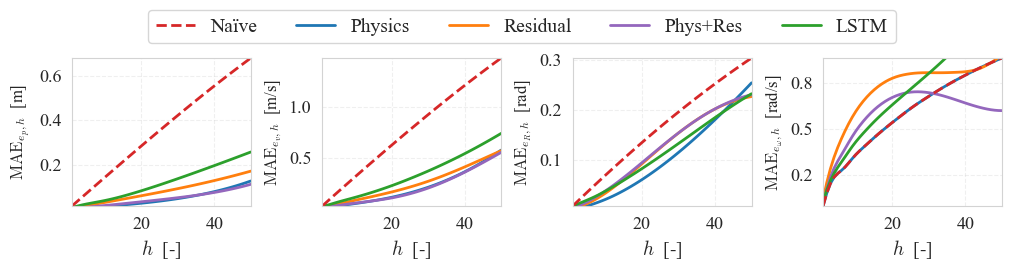

In [34]:
import matplotlib.pyplot as plt

# ============================================================
# === FIGURE: Position, Angular velocity, Orientation errors ==
# ============================================================

fig, axs = plt.subplots(1, 4, figsize=(12, 2), sharex=True)

metric_names = ["pos", "vel", "rot", "omega"]
ylabels = [
    r"$\mathrm{MAE}_{e_p,h}$  [m]",
    r"$\mathrm{MAE}_{e_v,h}$  [m/s]",
    r"$\mathrm{MAE}_{e_R,h}$  [rad]",
    r"$\mathrm{MAE}_{e_{\omega},h}$  [rad/s]"
]

# Plotting order: Baseline LAST
plot_order = ["Physics", "Residual", "Phys+Res", "LSTM", "Naïve"]

model_metrics = {
    "Physics":   metrics_phys,
    "Residual":  metrics_neur,
    "Phys+Res":  metrics_res,
    "LSTM":      metrics_lstm,
    "Naïve":  metrics_base,
}

model_styles = {
    "Physics": ('-', 'tab:blue'),
    "Residual":  ('-', 'tab:orange'),
    "Phys+Res":('-', 'tab:purple'),
    "LSTM":    ('-', 'tab:green'),
    "Naïve":('--', 'tab:red'),
}

from matplotlib.ticker import FormatStrFormatter

ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

for i, metric in enumerate(metric_names):
    ax = axs[i]

    # make tick numbers bigger
    ax.tick_params(labelsize=13, width=1.2, length=4)

    # <-- Add this line for .1f formatting
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Light grey axis box (same as torque-y)
    for spine in ax.spines.values():
        spine.set_edgecolor("lightgray")


    # Plot models in desired *drawing* order
    for model_name in plot_order:
        mm = model_metrics[model_name]
        horizons = np.array(list(mm[metric].keys()))
        values   = np.array(list(mm[metric].values()))

        ls, color = model_styles[model_name]
        ax.plot(horizons, values, ls, color=color,
                linewidth=2, markersize=4, label=model_name)

    ax.set_ylabel(ylabels[i], fontsize=12)
    min_val = min(metrics_base[metric].values())
    max_val = max(metrics_base[metric].values())
    ax.set_ylim(min_val, max_val)
    ax.set_xlabel("$h$  [-]", fontsize=14)
    ax.grid(True, alpha=0.3)

# === Shared Legend ===
handles, labels = axs[0].get_legend_handles_labels()

# Reorder legend so Baseline is FIRST
legend_order = ["Naïve", "Physics", "Residual", "Phys+Res", "LSTM"]
legend_handles = [handles[labels.index(m)] for m in legend_order]

fig.legend(
    legend_handles, legend_order,
    loc="upper center",
    ncols=5,
    bbox_to_anchor=(0.5, 1.15),
    fontsize=14
)

plt.subplots_adjust(top=0.86, bottom=0.12, hspace=0.25, wspace=0.4)
plt.savefig("new_metrics_models.pdf", bbox_inches='tight')
plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


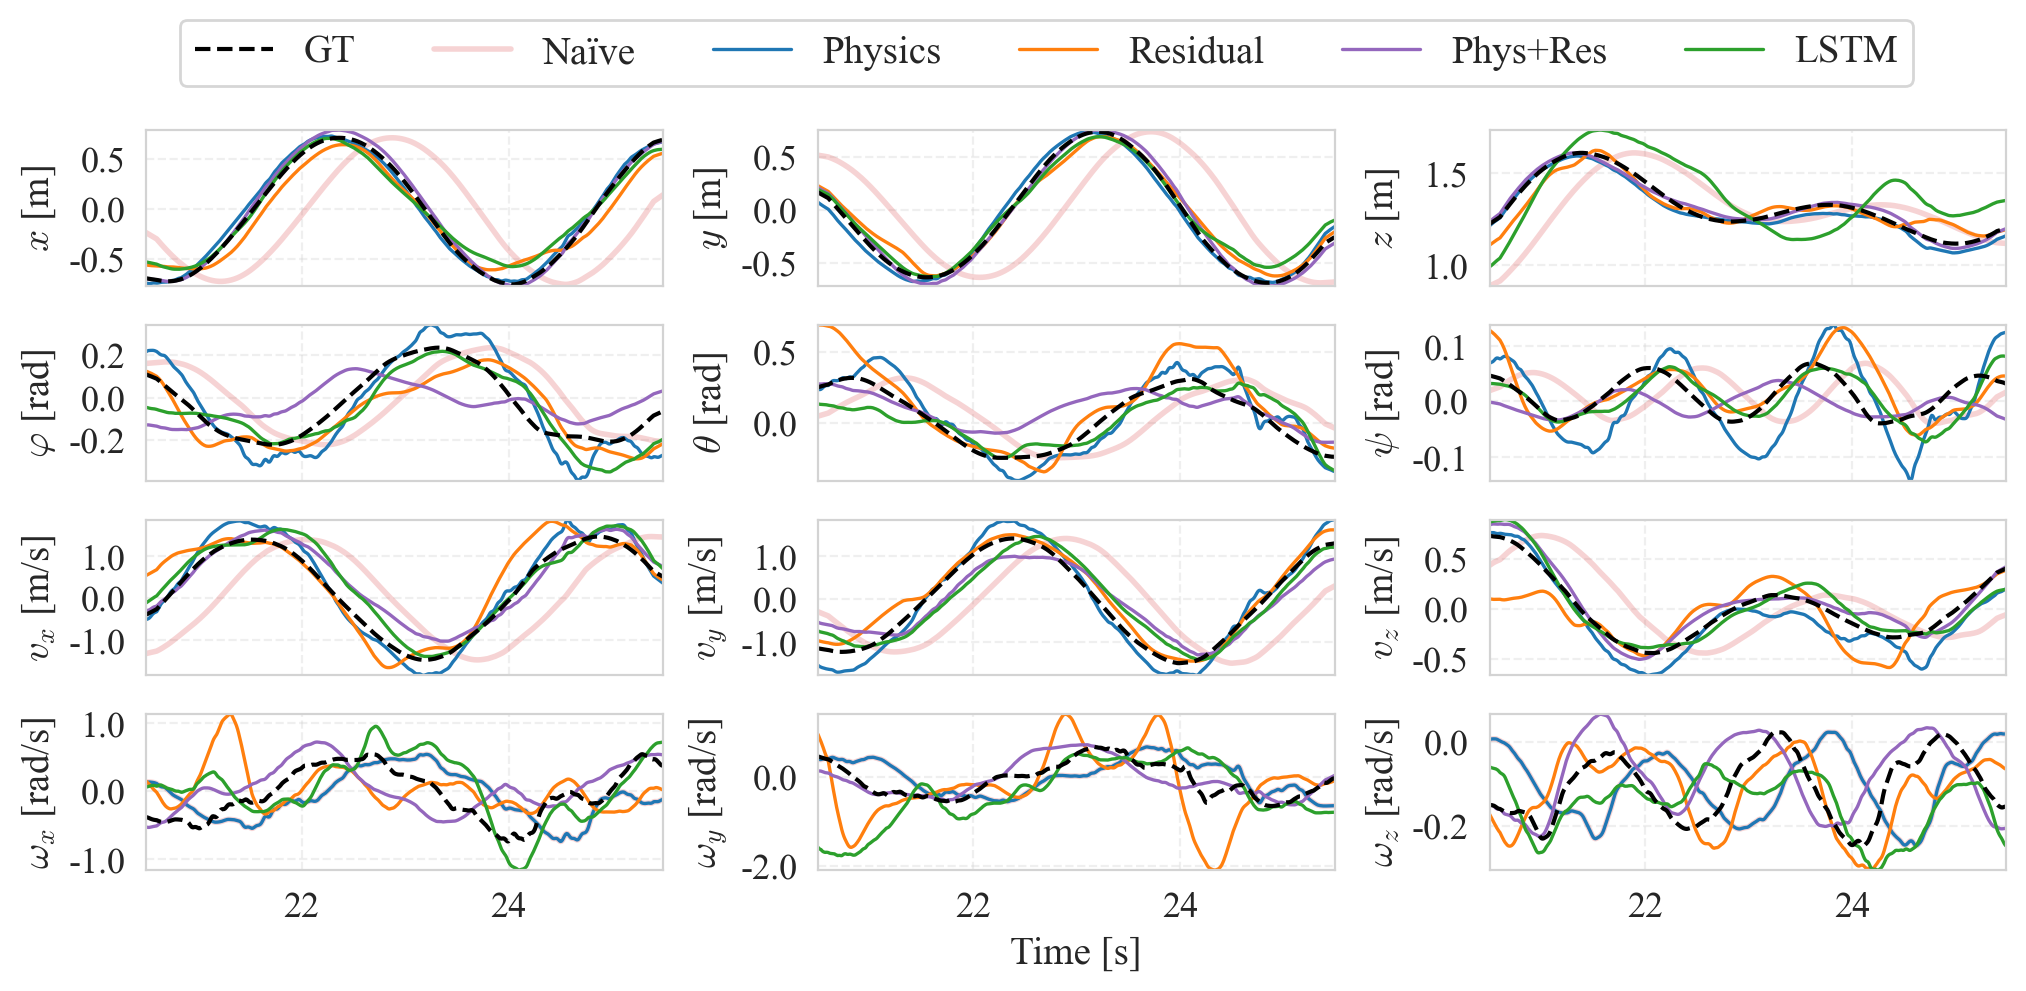

In [35]:
from matplotlib.ticker import FormatStrFormatter


def plot_multistate_predictions(h=50, N_start=0, N_end=None):
    """
    Create a 4x3 grid of time-series plots comparing true vs. predicted trajectories
    (h-step ahead) for each state variable.
    """

    if N_end is None:
        N_end = len(df_base) - h

    # --- State order (12 total) ---
    state_names = [
        "x", "y", "z",
        "roll", "pitch", "yaw",
        "vx", "vy", "vz",
        "wx", "wy", "wz"
    ]

    # --- Fancy axis labels ---
    state_labels = [
        [r"$x$ [m]", r"$y$ [m]", r"$z$ [m]"],
        [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
        [r"$v_x$ [m/s]", r"$v_y$ [m/s]", r"$v_z$ [m/s]"],
        [r"$\omega_x$ [rad/s]", r"$\omega_y$ [rad/s]", r"$\omega_z$ [rad/s]"]
    ]

    # --- Figure setup ---
    fig, axs = plt.subplots(4, 3, figsize=(12, 5), sharex=True, dpi=200)
    t = df_base["t"].values

    for r in range(4):
        for c in range(3):
            idx = r * 3 + c
            if idx >= len(state_names):
                continue

            state = state_names[idx]
            pred_col = f"{state}_pred_h{h}"
            ax = axs[r, c]

            # --- Smoothed signals ---
            neur = df_neur[pred_col][N_start:N_end].rolling(20, min_periods=1, center=True).mean()
            res  = df_res[pred_col][N_start:N_end].rolling(20, min_periods=1, center=True).mean()
            lstm = df_lstm[pred_col][N_start:N_end].rolling(20, min_periods=1, center=True).mean()
            base = df_base[pred_col][N_start:N_end].rolling(20, min_periods=1, center=True).mean()
            phys = df_phys[pred_col][N_start:N_end].rolling(20, min_periods=1, center=True).mean()
            true = df_base[state][N_start + h:N_end + h].rolling(20, min_periods=1, center=True).mean()

            # --- Plot ---
            ax.plot(t[N_start + h:N_end + h], base, '-', color='tab:red', label='Naïve', linewidth=2, alpha=0.2)
            ax.plot(t[N_start + h:N_end + h], phys, '-', color='tab:blue', label='Physics', linewidth=1.2)
            ax.plot(t[N_start + h:N_end + h], neur, '-', color='tab:orange', label='Residual', linewidth=1.2)
            ax.plot(t[N_start + h:N_end + h], res, '-', color='tab:purple', label='Phys+Res', linewidth=1.2)
            ax.plot(t[N_start + h:N_end + h], lstm, '-', color='tab:green', label='LSTM', linewidth=1.2)
            ax.plot(t[N_start + h:N_end + h], true, 'k--', label='GT', linewidth=1.5)

            # --- Aesthetics ---
            ax.set_ylabel(state_labels[r][c], fontsize=14, labelpad=10)
            ax.grid(True, alpha=0.3)

            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

            # Light grey axis box (same as torque-y)
            for spine in ax.spines.values():
                spine.set_edgecolor("lightgray")

            # make tick numbers bigger
            ax.tick_params(labelsize=13, width=1.2, length=4)

            if (r == 3) and (c == 1):
                ax.set_xlabel("Time [s]", fontsize=14)

    # --- Align y-labels properly ---
    fig.align_ylabels(axs[:, 0])

    # --- Shared legend (like 2nd figure) ---
    handles, labels = [], []
    for ax in axs.flat:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    # fig.legend(handles, labels, loc='upper center', ncols=6,
    #            bbox_to_anchor=(0.5, 1), fontsize=14, frameon=True)

    labelx = -0.17  # axes coords

    for ax in axs.flat:
        ax.yaxis.set_label_coords(labelx, 0.5)

    plt.subplots_adjust(top=0.86, bottom=0.12, hspace=0.25, wspace=0.3)

    # Reorder legend so Baseline is FIRST
    legend_order = ["GT", "Naïve", "Physics", "Residual", "Phys+Res", "LSTM"]
    legend_handles = [handles[labels.index(m)] for m in legend_order]

    fig.legend(
    legend_handles, legend_order,
    loc="upper center",
    ncols=6,
    bbox_to_anchor=(0.5, .99),
    fontsize=14
    )

    plt.savefig('new_lineplots_models.pdf', bbox_inches='tight')
    plt.show()

N_start = 2000
N_end = N_start + 500
plot_multistate_predictions(h=50, N_start=N_start, N_end=N_end)

In [36]:
import numpy as np
import pandas as pd

# ============================================================
# === CONFIG
# ============================================================
H_TARGETS = [1, 10, 50]

model_order = ["Naïve", "Physics", "Residual", "Phys+Res", "LSTM"]

model_metrics = {
    "Naïve": metrics_base,
    "Physics":  metrics_phys,
    "Residual": metrics_neur,
    "Phys+Res": metrics_res,
    "LSTM":     metrics_lstm,
}

# ============================================================
# === Format for standard MAE columns
# ============================================================
def bold_best(col):
    arr = np.asarray(col, dtype=float)
    best = np.min(arr)
    out = []
    for x in arr:
        if abs(x - best) < 1e-12:
            out.append(f"\\textbf{{{x:.4f}}}")
        else:
            out.append(f"{x:.4f}")
    return out

# ============================================================
# === Format for 1:50 italic CUMULATIVE SIM-ERROR columns
# ============================================================
def italic_bold_best(col):
    arr = np.asarray(col, dtype=float)
    best = np.min(arr)
    out = []
    for x in arr:
        s = f"{x:.4f}"
        if abs(x - best) < 1e-12:
            out.append(f"\\textbf{{\\textit{{{s}}}}}")
        else:
            out.append(f"\\textit{{{s}}}")
    return out

# ============================================================
# === Compute cumulative simulation error (sum over h=1..50)
# ============================================================
def compute_simerr(metric_dict):
    sim_p = sum(metric_dict["pos"][h] for h in range(1, 51))
    sim_v = sum(metric_dict["vel"][h] for h in range(1, 51))
    sim_R = sum(metric_dict["rot"][h] for h in range(1, 51))
    sim_w = sum(metric_dict["omega"][h] for h in range(1, 51))
    return sim_p, sim_v, sim_R, sim_w

# ============================================================
# === Build rows
# ============================================================
rows = []
for model_name in model_order:
    mm = model_metrics[model_name]

    pos_vals = [mm["pos"][h] for h in H_TARGETS]
    vel_vals = [mm["vel"][h] for h in H_TARGETS]
    rot_vals = [mm["rot"][h] for h in H_TARGETS]
    omg_vals = [mm["omega"][h] for h in H_TARGETS]

    sim_p, sim_v, sim_R, sim_w = compute_simerr(mm)

    rows.append([
        model_name,
        *pos_vals, sim_p,
        *vel_vals, sim_v,
        *rot_vals, sim_R,
        *omg_vals, sim_w,
    ])

# ============================================================
# === DataFrame structure (with the italic 1:50 columns)
# ============================================================
columns = (
    ["Model"] +
    [f"$p_{{h={h}}}$" for h in H_TARGETS] + [r"$\textit{p_{h=1{:}50}}$"] +
    [f"$v_{{h={h}}}$" for h in H_TARGETS] + [r"$\textit{v_{h=1{:}50}}$"] +
    [f"$R_{{h={h}}}$" for h in H_TARGETS] + [r"$\textit{R_{h=1{:}50}}$"] +
    [f"$\omega_{{h={h}}}$" for h in H_TARGETS] + [r"$\textit{\omega_{h=1{:}50}}$"]
)

df = pd.DataFrame(rows, columns=columns)

# ============================================================
# === Apply formatting: MAE columns normal-bold, SimErr italic+bold
# ============================================================
mae_cols = []
sim_cols = []

for col in columns[1:]:
    if "1:50" in col:
        sim_cols.append(col)
    else:
        mae_cols.append(col)

for col in mae_cols:
    df[col] = bold_best(df[col].astype(float))

for col in sim_cols:
    df[col] = italic_bold_best(df[col].astype(float))

# ============================================================
# === Build LaTeX
# ============================================================
latex_body = df.to_latex(
    index=False,
    escape=False,
    header=False,
).strip()

lines = latex_body.splitlines()
data_rows = lines[1:-1]

latex_final = r"""
\begin{table*}[t]
    \centering
    \caption{Numerical performance at $h=1,10,50$. The italic column reports the cumulative simulation error (sum of MAEs over $h=1..50$).}
    \setlength{\tabcolsep}{3pt}
    \scriptsize
    \renewcommand{\arraystretch}{1.2}
    \begin{tabular}{l|cccc|cccc|cccc|cccc}
        \toprule
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{p,h}$ [m]}
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{v,h}$ [m/s]}
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{R,h}$ [rad]}
        & \multicolumn{4}{c}{$\mathrm{MAE}_{\omega,h}$ [rad/s]}\\[1mm]

        Model
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}\\
        \midrule
""" + "\n".join(data_rows) + r"""
        \bottomrule
    \end{tabular}
    \label{tab:numerical_performance}
\end{table*}
"""

print(latex_final)



\begin{table*}[t]
    \centering
    \caption{Numerical performance at $h=1,10,50$. The italic column reports the cumulative simulation error (sum of MAEs over $h=1..50$).}
    \setlength{\tabcolsep}{3pt}
    \scriptsize
    \renewcommand{\arraystretch}{1.2}
    \begin{tabular}{l|cccc|cccc|cccc|cccc}
        \toprule
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{p,h}$ [m]}
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{v,h}$ [m/s]}
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{R,h}$ [rad]}
        & \multicolumn{4}{c}{$\mathrm{MAE}_{\omega,h}$ [rad/s]}\\m]

        Model
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}\\
        \midrule
\toprule
\midrule
Naïve & 0.0143 & 0.1430 & 0.6797 & 17.7878 & 0.0329 & 0.3182 & 1.4749 & 38.9241 & 0.0071 & 0.0692 & 0.3041 & 8.2138 & \textbf{0.0796

<>:88: SyntaxWarning: invalid escape sequence '\o'
<>:88: SyntaxWarning: invalid escape sequence '\o'
C:\Users\riccardo.busetto\AppData\Local\Temp\ipykernel_7948\2576028859.py:88: SyntaxWarning: invalid escape sequence '\o'
  [f"$\omega_{{h={h}}}$" for h in H_TARGETS] + [r"$\textit{\omega_{h=1{:}50}}$"]


In [15]:
import numpy as np
import pandas as pd

# ============================================================
# === CONFIG
# ============================================================
H_TARGETS = [1, 10, 50]

model_order = ["Naïve", "Physics", "Residual", "Phys+Res", "LSTM"]

model_metrics = {
    "Naïve": metrics_base,
    "Physics":  metrics_phys,
    "Residual":   metrics_neur,
    "Phys+Res": metrics_res,
    "LSTM":     metrics_lstm,
}

num_params = {
    "Naïve":   0,
    "Physics":    0,
    "Residual":   30_000,
    "Phys+Res":   38_000,
    "LSTM":       52_000,
}

T_inf = {
    "Naïve":  0.005,
    "Physics":   0.025,
    "Residual":  0.045,
    "Phys+Res":  0.060,
    "LSTM":      0.110,
}

FLOPs = {
    "Naïve":  0.01,
    "Physics":   0.20,
    "Residual":  1.30,
    "Phys+Res":  1.60,
    "LSTM":      2.20,
}

# ============================================================
# === Bold best entries
# ============================================================
def bold_best(col):
    arr = np.asarray(col, dtype=float)
    best = np.min(arr)
    out = []
    for x in arr:
        if abs(x - best) < 1e-12:
            out.append(f"\\textbf{{{x:.4f}}}")
        else:
            out.append(f"{x:.4f}")
    return out

# ============================================================
# === Build rows
# ============================================================
rows = []
for model_name in model_order:
    mm = model_metrics[model_name]

    pos_vals = [mm["pos"][h] for h in H_TARGETS]
    vel_vals = [mm["vel"][h] for h in H_TARGETS]
    omg_vals = [mm["omega"][h] for h in H_TARGETS]
    rot_vals = [mm["rot"][h] for h in H_TARGETS]

    rows.append([
        model_name,
        *pos_vals,
        *vel_vals,
        *omg_vals,
        *rot_vals,
        num_params[model_name],
        T_inf[model_name],
        FLOPs[model_name],
    ])

# ------------------------------------------------------------
# DataFrame with columns
# ------------------------------------------------------------
columns = (
    ["Model"] +
    [f"$p_{{{h}}}$" for h in H_TARGETS] +
    [f"$v_{{{h}}}$" for h in H_TARGETS] +
    [f"$R_{{{h}}}$" for h in H_TARGETS] +
    [f"$\\omega_{{{h}}}$" for h in H_TARGETS] +
    ["\\#params", "$T_{inf}$ [ms]", "FLOPs [M]"]
)

df = pd.DataFrame(rows, columns=columns)

# Bold MAE columns only
for col in columns[1:10]:
    df[col] = bold_best(df[col].astype(float))

# ============================================================
# === Build FULL LaTeX TABLE
# ============================================================
latex_body = df.to_latex(
    index=False,
    escape=False,
    header=False,
).strip()

# Extract rows
lines = latex_body.splitlines()
data_rows = lines[1:-1]   # remove start/end markup

# ============================================================
# === Compose the final table with multicolumn header
# ============================================================
latex_final = r"""
\begin{table*}[t]
    \centering
    \setlength{\tabcolsep}{6pt}
    \renewcommand{\arraystretch}{1.2}
    \begin{tabular}{l|ccc|ccc|ccc|ccc}
        \toprule
        & \multicolumn{3}{c|}{$\mathrm{MAE}_{p,h}$ [m]}
        & \multicolumn{3}{c|}{$\mathrm{MAE}_{v,h}$ [m/s]}
        & \multicolumn{3}{c|}{$\mathrm{MAE}_{R,h}$ [rad]}
        & \multicolumn{3}{c|}{$\mathrm{MAE}_{\omega,h}$ [rad/s]}
        & \multicolumn{3}{c}{$\text{Model Info}$} \\[1mm]
        Model
        & $h\!=\!1$ & $h\!=\!10$ & $h\!=\!50$
        & $h\!=\!1$ & $h\!=\!10$ & $h\!=\!50$
        & $h\!=\!1$ & $h\!=\!10$ & $h\!=\!50$
        & \#params & $T_{inf}$ [ms] & FLOPs [M] \\
        \midrule
""" + "\n".join(data_rows) + r"""
        \bottomrule
    \end{tabular}
    \caption{Numerical performance comparison of all models at three
    representative prediction horizons: 1-step, 10-step, and 50-step ahead.
    Errors are reported as mean absolute error (MAE) for position
    ($\mathrm{MAE}_{p}$), angular velocity ($\mathrm{MAE}_{\omega}$), and
    orientation ($\mathrm{MAE}_{R}$).}
    \label{tab:numerical_performance}
\end{table*}
"""

print(latex_final)


\begin{table*}[t]
    \centering
    \setlength{\tabcolsep}{6pt}
    \renewcommand{\arraystretch}{1.2}
    \begin{tabular}{l|cccc|cccc|cccc|cccc}
        \toprule
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{p,h}$ [m]}
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{v,h}$ [m/s]}
        & \multicolumn{4}{c|}{$\mathrm{MAE}_{R,h}$ [rad]}
        & \multicolumn{4}{c}{$\mathrm{MAE}_{\omega,h}$ [rad/s]}\\m]

        Model
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
        & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}\\
        \midrule
\toprule
\midrule
Baseline & 0.0143 & 0.1430 & 0.6797 & 17.7878 & 0.0329 & 0.3182 & 1.4749 & 38.9241 & 0.0071 & 0.0692 & 0.3041 & 8.2138 & \textbf{0.0796} & \textbf{0.3596} & 0.8837 & 29.0866 \\
Physics & \textbf{0.0013} & \textbf{0.0126} & 0.1269 & \textbf{2.3223} & \textbf{0.0080} & \textbf{0.0570} & 0.

<>:88: SyntaxWarning: invalid escape sequence '\o'
<>:88: SyntaxWarning: invalid escape sequence '\o'
C:\Users\riccardo.busetto\AppData\Local\Temp\ipykernel_24720\1870604839.py:88: SyntaxWarning: invalid escape sequence '\o'
  [f"$\omega_{{h={h}}}$" for h in H_TARGETS] + [r"$\mathit{\omega_{h=1{:}50}}$"]


In [21]:
lambda_ = .02
N = 50
weights = np.exp(-lambda_ * np.arange(N))
# weights = weights / weights.sum()  # normalize to 1
for w in weights:
    print(w)

1.0
0.9801986733067553
0.9607894391523232
0.9417645335842487
0.9231163463866358
0.9048374180359595
0.8869204367171575
0.8693582353988059
0.8521437889662113
0.835270211411272
0.8187307530779818
0.8025187979624785
0.7866278610665535
0.7710515858035663
0.7557837414557255
0.7408182206817179
0.7261490370736909
0.7117703227626097
0.697676326071031
0.6838614092123558
0.6703200460356393
0.6570468198150567
0.6440364210831414
0.631283645506926
0.6187833918061408
0.6065306597126334
0.5945205479701944
0.5827482523739896
0.5712090638488149
0.559898366565402
0.5488116360940264
0.5379444375946745
0.5272924240430485
0.5168513344916992
0.5066169923655895
0.49658530379140947
0.4867522559599717
0.4771139155210344
0.46766642700990924
0.4584060113052235
0.44932896411722156
0.44043165450599925
0.43171052342907973
0.4231620823177488
0.4147829116815814
0.4065696597405991
0.39851904108451414
0.3906278353585211
0.38289288597511206
0.37531109885139957


/tmp/ipykernel_267516/3692333169.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_artist=True, labels=labels,
/tmp/ipykernel_267516/3692333169.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_artist=True, labels=labels,
/tmp/ipykernel_267516/3692333169.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_artist=True, labels=labels,
/tmp/ipykernel_267516/3692333169.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be drop

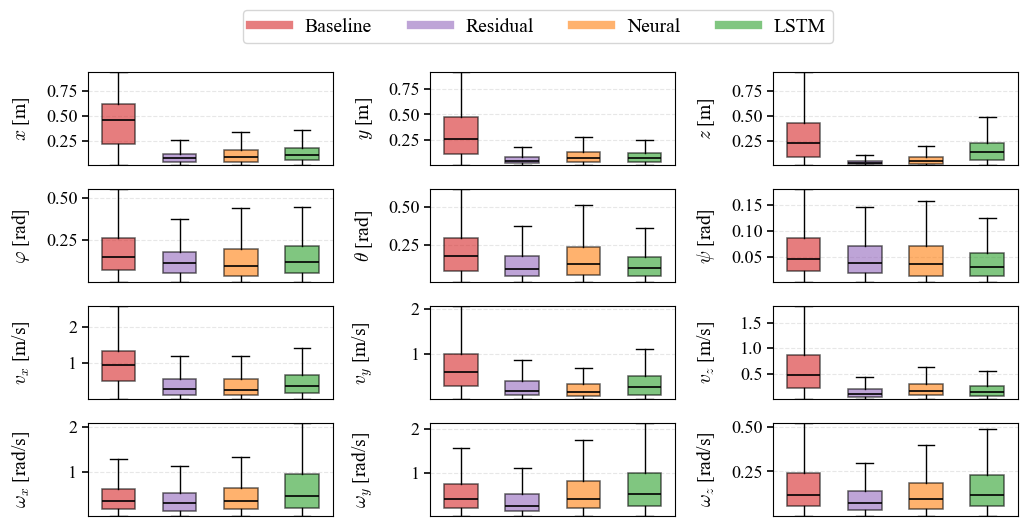

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multistate_boxplots(df_base, df_lstm, df_neur, df_res,
                             h=50, N_start=0, N_end=None, max_outliers=None):
    """
    Create a 4x3 grid of boxplots showing absolute errors for each model and state.
    Matches the aesthetic of plot_multistate_predictions.

    Args:
        df_base, df_lstm, df_neur, df_res : DataFrames
            Containing columns like '<state>_pred_h<h>'.
        h : int
            Prediction horizon.
        N_start, N_end : int
            Index range for samples.
        max_outliers : int or None
            If set, limits the number of largest error samples kept (useful to reduce extreme tails).
    """

    if N_end is None:
        N_end = len(df_base) - h

    # --- State order (12 total) ---
    state_names = [
        "x", "y", "z",
        "roll", "pitch", "yaw",
        "vx", "vy", "vz",
        "wx", "wy", "wz"
    ]

    # --- Fancy axis labels ---
    state_labels = [
        [r"$x$ [m]", r"$y$ [m]", r"$z$ [m]"],
        [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
        [r"$v_x$ [m/s]", r"$v_y$ [m/s]", r"$v_z$ [m/s]"],
        [r"$\omega_x$ [rad/s]", r"$\omega_y$ [rad/s]", r"$\omega_z$ [rad/s]"]
    ]

    # --- Model colors ---
    colors = {
        "Naïve": "tab:red",
        "Residual": "tab:purple",
        "Neural": "tab:orange",
        "LSTM": "tab:green",
    }

    fig, axs = plt.subplots(4, 3, figsize=(12, 6), dpi=100)
    axs = axs.flatten()

    for r in range(4):
        for c in range(3):
            idx = r * 3 + c
            if idx >= len(state_names):
                continue

            state = state_names[idx]
            pred_col = f"{state}_pred_h{h}"
            ax = axs[idx]

            # --- Compute absolute errors ---
            true = df_base[state].values[N_start + h:N_end + h]
            base = np.abs(df_base[pred_col].values[N_start:N_end] - true)
            neur = np.abs(df_neur[pred_col].values[N_start:N_end] - true)
            lstm = np.abs(df_lstm[pred_col].values[N_start:N_end] - true)
            res  = np.abs(df_res[pred_col].values[N_start:N_end] - true)

            # --- Optionally limit outliers ---
            if max_outliers is not None:
                def limit_outliers(arr, n=max_outliers):
                    if len(arr) > n:
                        cutoff = np.partition(arr, -n)[-n]  # nth largest
                        arr = np.clip(arr, None, cutoff)
                    return arr
                base, neur, lstm, res = map(limit_outliers, [base, neur, lstm, res])

            # --- Prepare data ---
            data = [base, res, neur, lstm]
            labels = list(colors.keys())

            # --- Boxplot ---
            box = ax.boxplot(data, patch_artist=True, labels=labels,
                             widths=0.55,
                             showfliers=False,
                             medianprops=dict(color='black', linewidth=1.2),
                             boxprops=dict(linewidth=1.1),
                             whiskerprops=dict(linewidth=1.0),
                             capprops=dict(linewidth=1.0),
                             flierprops=dict(marker='.', markersize=2, alpha=0.4))

            # --- Color boxes ---
            for patch, key in zip(box['boxes'], colors.keys()):
                patch.set_facecolor(colors[key])
                patch.set_alpha(0.6)

            # # --- Style ---
            # ax.set_ylabel(state_labels[r][c], fontsize=14, labelpad=10)
            # ax.grid(True, alpha=0.3)
            # ax.tick_params(labelsize=13, width=1.2, length=4)
            # ax.set_xticklabels(labels, rotation=20, fontsize=12)
            # --- Style ---
            ax.set_ylabel(state_labels[r][c], fontsize=14, labelpad=10)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=13, width=1.2, length=4)

            # REMOVE x labels
            ax.set_xticks([])
            ax.set_xlabel("")


    # --- Shared legend ---
    legend_elements = [
        plt.Line2D([0], [0], color=c, lw=6, label=label, alpha=0.6)
        for label, c in colors.items()
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncols=4,
               bbox_to_anchor=(0.5, .98), fontsize=14, frameon=True)
    fig.align_ylabels()
    plt.subplots_adjust(top=0.86, bottom=0.12, hspace=0.25, wspace=0.4)
    plt.savefig('boxplots_models.pdf')
    plt.show()

# Standard usage
plot_multistate_boxplots(df_base, df_lstm, df_neur, df_res, h=50, N_start=0, N_end=None, max_outliers=1)